# Predictive modelling and regression analysis

This notebook applies multiple linear regression and binary logistic regression to the Adult Income dataset (1994 US Census).

| Part  | Dependent variable (Y) |
|---|---|
| Multiple linear regression |  `hours-per-week` (continuous) |
| Binary logistic regression |  `income` (>50K = 1, ≤50K = 0) |

The models are fitted on the training file (`adult.data`) and evaluated on the separate test file (`adult.test`).

The default significance level is α = 0.05.

## Getting ready

Import libraries.

In [1]:
# Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from scipy import stats

ALPHA = 0.05
RANDOM_STATE = 42

print("Libraries loaded.")

Libraries loaded.


## Load the data

The data was cleaned and encoded in the descriptive statistics notebook and saved to `cleaned_data`. Both files contain the 42 encoded predictors plus the target `income` (1 = >50K, 0 = ≤50K).

In [2]:
train = pd.read_csv("cleaned_data/train_encoded.csv")
test = pd.read_csv("cleaned_data/test_encoded.csv")

print("Training shape:", train.shape)   # expected (30139, 43): 42 predictors + income
print("Test shape:    ", test.shape)    # expected (15055, 43)
print("Missing values (train):", train.isna().sum().sum())
print("Missing values (test): ", test.isna().sum().sum())
print("Income values:", sorted(train["income"].unique().tolist()))

display(train.head())

Training shape: (30139, 43)
Test shape:     (15055, 43)
Missing values (train): 0
Missing values (test):  0
Income values: [0, 1]


,age,education-num,sex,hours-per-week,capital-gain-log,capital-loss-log,has-capital,is_us,workclass_Local-gov,workclass_Private,...,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White,income
0,39,13,1,40,7.684784,0.0,1,1,0,0,...,1,0,0,0,0,0,0,0,1,0
1,50,13,1,13,0.000000,0.0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
2,38,9,1,40,0.000000,0.0,0,1,0,1,...,1,0,0,0,0,0,0,0,1,0
3,53,7,1,40,0.000000,0.0,0,1,0,1,...,0,0,0,0,0,0,1,0,0,0
4,28,13,0,40,0.000000,0.0,0,0,0,1,...,0,0,0,0,1,0,1,0,0,0


# Multiple linear regression

Variables:
- Dependent variable (Y): `hours-per-week`
- Independent variables (X):
  - `age` (years)
  - `education-num` (education level, 1–16)
  - `sex` (1 = Male, 0 = Female)

#### Prepare the data and display summary statistics

In [3]:
linear_predictors = ["age", "education-num", "sex"]
linear_target = "hours-per-week"

def prepare_linear_data(data):
    # In the encoded data, sex is already 1 = Male, 0 = Female
    prepared = data[linear_predictors + [linear_target]].copy()
    return prepared

linear_train = prepare_linear_data(train)
linear_test = prepare_linear_data(test)

print("Training data shape:", linear_train.shape)
print("Test data shape:    ", linear_test.shape)

display(linear_train.head())

print("Summary statistics (training data)")
display(linear_train.describe().T.round(3))

Training data shape: (30139, 4)
Test data shape:     (15055, 4)


,age,education-num,sex,hours-per-week
0,39,13,1,40
1,50,13,1,13
2,38,9,1,40
3,53,7,1,40
4,28,13,0,40


Summary statistics (training data)


,count,mean,std,min,25%,50%,75%,max
age,30139.0,38.442,13.131,17.0,28.0,37.0,47.0,90.0
education-num,30139.0,10.123,2.549,1.0,9.0,10.0,13.0,16.0
sex,30139.0,0.676,0.468,0.0,0.0,1.0,1.0,1.0
hours-per-week,30139.0,40.935,11.979,1.0,40.0,40.0,45.0,99.0


#### Correlation matrix and significance testing

Pearson correlation between every pair of variables. For each pair:

- H0: ρ = 0 (no linear correlation)
- H1: ρ ≠ 0

,age,education-num,sex,hours-per-week
age,1.0000,0.0432,0.0818,0.1013
education-num,0.0432,1.0000,0.0060,0.1528
sex,0.0818,0.0060,1.0000,0.2311
hours-per-week,0.1013,0.1528,0.2311,1.0000


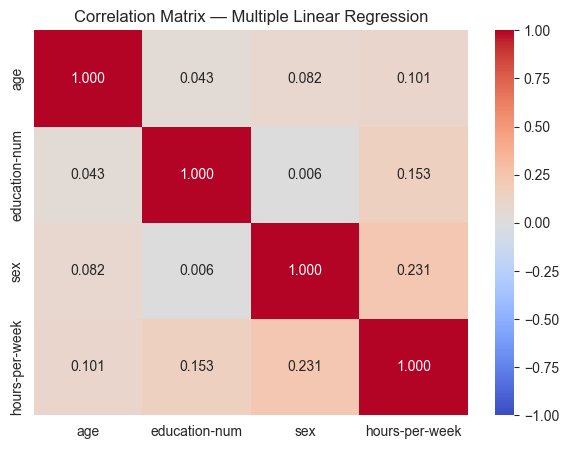

H0: ρ = 0    H1: ρ ≠ 0


,Variable 1,Variable 2,Correlation (r),p-value,Significant
0,age,education-num,0.0432,6.214972e-14,Yes
1,age,sex,0.0818,6.059583e-46,Yes
2,age,hours-per-week,0.1013,1.228029e-69,Yes
3,education-num,sex,0.0060,2.936613e-01,No
4,education-num,hours-per-week,0.1528,6.131332e-157,Yes
5,sex,hours-per-week,0.2311,0.000000e+00,Yes


In [4]:
correlation_matrix = linear_train.corr(method="pearson")

display(correlation_matrix.round(4))

plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix — Multiple Linear Regression")
plt.show()


# Significance tests for all correlations

correlation_results = []
columns = linear_train.columns

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):

        var1 = columns[i]
        var2 = columns[j]

        r, p_value = stats.pearsonr(linear_train[var1], linear_train[var2])

        correlation_results.append({
            "Variable 1": var1,
            "Variable 2": var2,
            "Correlation (r)": round(r, 4),
            "p-value": p_value,
            "Significant": "Yes" if p_value < ALPHA else "No"
        })

correlation_significance = pd.DataFrame(correlation_results)

print("H0: ρ = 0    H1: ρ ≠ 0")
display(correlation_significance)

#### Scatter plots

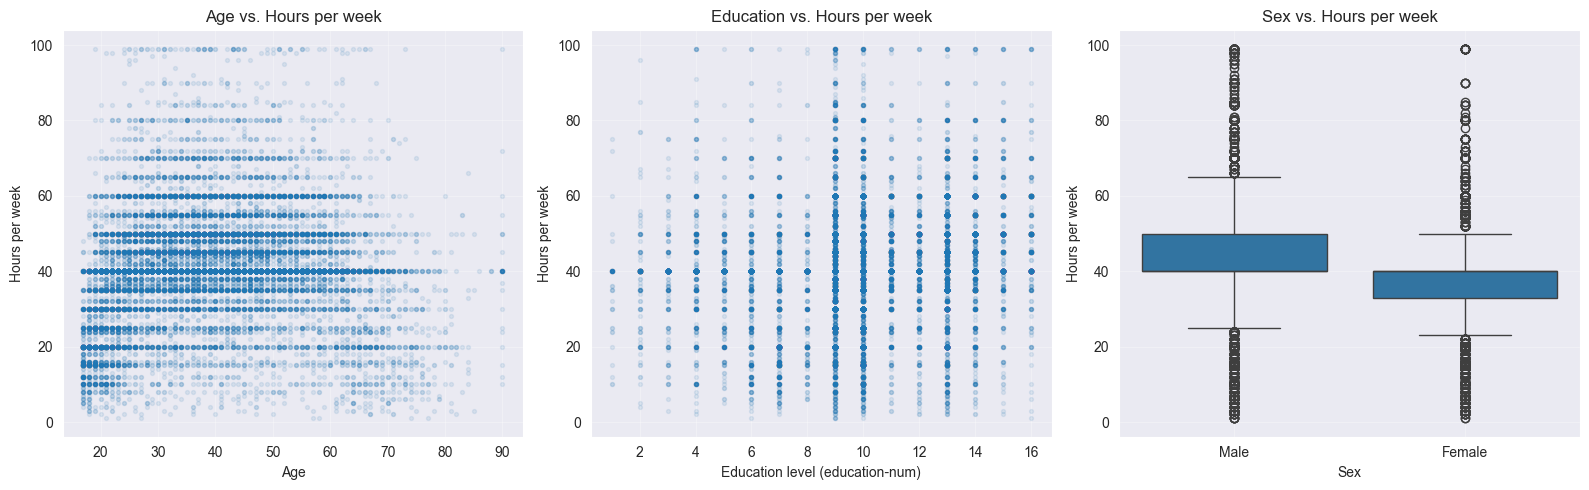

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(linear_train["age"], linear_train["hours-per-week"], alpha=0.1, s=8)
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Hours per week")
axes[0].set_title("Age vs. Hours per week")

axes[1].scatter(linear_train["education-num"], linear_train["hours-per-week"], alpha=0.1, s=8)
axes[1].set_xlabel("Education level (education-num)")
axes[1].set_ylabel("Hours per week")
axes[1].set_title("Education vs. Hours per week")

sns.boxplot(
    x=linear_train["sex"].map({0: "Female", 1: "Male"}),
    y=linear_train["hours-per-week"],
    ax=axes[2]
)
axes[2].set_xlabel("Sex")
axes[2].set_ylabel("Hours per week")
axes[2].set_title("Sex vs. Hours per week")

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Model fitting: coefficients and regression equation

The model is fitted on the training data. The same coefficients are estimated with scikit-learn (`LinearRegression`) and with statsmodels (`OLS`), which also gives the significance tests.

In [6]:
X_train_linear = linear_train[linear_predictors]
y_train_linear = linear_train[linear_target]

X_test_linear = linear_test[linear_predictors]
y_test_linear = linear_test[linear_target]

print("Training observations:", len(X_train_linear))
print("Testing observations: ", len(X_test_linear))

# Fit multiple regression model (scikit-learn)

linear_model = LinearRegression()
linear_model.fit(X_train_linear, y_train_linear)

linear_intercept = linear_model.intercept_
linear_coefficients = pd.Series(linear_model.coef_, index=linear_predictors)

print("\nMultiple Linear Regression model")
print("Coefficients:")
print(f"Intercept (b0) = {linear_intercept:.6f}")
for variable, coefficient in linear_coefficients.items():
    print(f"{variable} coefficient = {coefficient:.6f}")

print("\nEstimated regression equation:")
equation = f"hours-per-week = {linear_intercept:.4f}"
for variable, coefficient in linear_coefficients.items():
    sign = "+" if coefficient >= 0 else "-"
    equation += f" {sign} {abs(coefficient):.4f} × {variable}"
print(equation)


# ============================================================
# Using Ordinary Least Squares (OLS) method
# ============================================================

X_train_linear_const = sm.add_constant(X_train_linear)

ols_linear_model = sm.OLS(y_train_linear, X_train_linear_const).fit()

print(ols_linear_model.summary())

Training observations: 30139
Testing observations:  15055

Multiple Linear Regression model
Coefficients:
Intercept (b0) = 27.325659
age coefficient = 0.069895
education-num coefficient = 0.696413
sex coefficient = 5.731078

Estimated regression equation:
hours-per-week = 27.3257 + 0.0699 × age + 0.6964 × education-num + 5.7311 × sex
                            OLS Regression Results                            
Dep. Variable:         hours-per-week   R-squared:                       0.082
Model:                            OLS   Adj. R-squared:                  0.082
Method:                 Least Squares   F-statistic:                     899.4
Date:                Wed, 07 Oct 2026   Prob (F-statistic):               0.00
Time:                        12:09:50   Log-Likelihood:            -1.1631e+05
No. Observations:               30139   AIC:                         2.326e+05
Df Residuals:                   30135   BIC:                         2.327e+05
Df Model:                       

#### Testing for significance (*t*-tests)

For each coefficient:
- H0: bᵢ = 0 (the variable is not a significant predictor)
- H1: bᵢ ≠ 0

In [7]:
print("t-tests for individual regression coefficients")

t_test_results = []

for variable in linear_predictors:

    t_stat = ols_linear_model.tvalues[variable]
    p_value = ols_linear_model.pvalues[variable]

    print(f"\n{variable}")
    print(f"H0: b({variable}) = 0")
    print(f"H1: b({variable}) ≠ 0")
    print(f"t-statistic = {t_stat:.4f}")
    print(f"p-value = {p_value:.6f}")

    if p_value < ALPHA:
        print(f"p-value < {ALPHA}: Reject H0. {variable} is a statistically significant predictor.")
    else:
        print(f"p-value >= {ALPHA}: Do not reject H0. There is insufficient evidence that {variable} is a significant predictor.")

    t_test_results.append({
        "Variable": variable,
        "Coefficient": ols_linear_model.params[variable],
        "t-statistic": t_stat,
        "p-value": p_value,
        "Significant": "Yes" if p_value < ALPHA else "No"
    })

display(pd.DataFrame(t_test_results).round(6))

t-tests for individual regression coefficients

age
H0: b(age) = 0
H1: b(age) ≠ 0
t-statistic = 13.8243
p-value = 0.000000
p-value < 0.05: Reject H0. age is a statistically significant predictor.

education-num
H0: b(education-num) = 0
H1: b(education-num) ≠ 0
t-statistic = 26.8244
p-value = 0.000000
p-value < 0.05: Reject H0. education-num is a statistically significant predictor.

sex
H0: b(sex) = 0
H1: b(sex) ≠ 0
t-statistic = 40.4451
p-value = 0.000000
p-value < 0.05: Reject H0. sex is a statistically significant predictor.


,Variable,Coefficient,t-statistic,p-value,Significant
0,age,0.069895,13.824337,0.0,Yes
1,education-num,0.696413,26.824365,0.0,Yes
2,sex,5.731078,40.445062,0.0,Yes


#### Testing for significance (*F*-test)

In [8]:
print("F-test for the overall regression model")
print("H0: b1 = b2 = b3 = 0")
print("H1: At least one b coefficient is not equal to 0")

f_stat_linear = ols_linear_model.fvalue
f_p_value_linear = ols_linear_model.f_pvalue

print(f"F-statistic = {f_stat_linear:.4f}")
print(f"p-value = {f_p_value_linear:.6f}")

if f_p_value_linear < ALPHA:
    print(f"p-value < {ALPHA}: Reject H0. The regression model is statistically significant.")
else:
    print(f"p-value >= {ALPHA}: Do not reject H0. There is insufficient evidence that the regression model is statistically significant.")

F-test for the overall regression model
H0: b1 = b2 = b3 = 0
H1: At least one b coefficient is not equal to 0
F-statistic = 899.3626
p-value = 0.000000
p-value < 0.05: Reject H0. The regression model is statistically significant.


#### Test set predictions

In [9]:
y_pred_linear = linear_model.predict(X_test_linear)

linear_predictions = X_test_linear.copy()

linear_predictions["Actual"] = y_test_linear.values
linear_predictions["Predicted"] = y_pred_linear
linear_predictions["Residual"] = linear_predictions["Actual"] - linear_predictions["Predicted"]

display(linear_predictions.head(15).round(3))

,age,education-num,sex,Actual,Predicted,Residual
0,25,7,1,40,39.679,0.321
1,38,9,1,50,41.980,8.020
2,28,12,1,40,43.371,-3.371
3,44,10,1,40,43.096,-3.096
4,34,6,1,30,39.612,-9.612
5,63,15,1,32,47.906,-15.906
6,24,10,0,40,35.967,4.033
7,55,4,1,10,39.687,-29.687
8,65,9,1,40,43.868,-3.868
9,36,13,1,40,44.626,-4.626


#### Actual vs. predicted plot

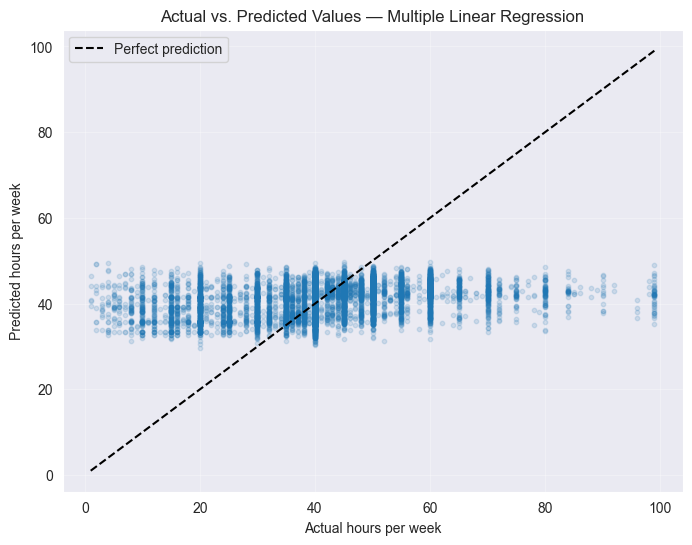

In [10]:
plt.figure(figsize=(8, 6))

plt.scatter(
    linear_predictions["Actual"],
    linear_predictions["Predicted"],
    alpha=0.15,
    s=10
)

min_value = min(linear_predictions["Actual"].min(), linear_predictions["Predicted"].min())
max_value = max(linear_predictions["Actual"].max(), linear_predictions["Predicted"].max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    color="black",
    label="Perfect prediction"
)

plt.xlabel("Actual hours per week")
plt.ylabel("Predicted hours per week")
plt.title("Actual vs. Predicted Values — Multiple Linear Regression")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### Predictive performance (model evaluation)

In [11]:
def calculate_mape(y_true, y_pred):
    """
    Calculate Mean Absolute Percentage Error (MAPE).
    Observations with actual values equal to zero
    are excluded to avoid division by zero.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    nonzero_mask = y_true != 0

    if nonzero_mask.sum() == 0:
        return np.nan

    return np.mean(
        np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])
    ) * 100


mae_linear = mean_absolute_error(y_test_linear, y_pred_linear)
mse_linear = mean_squared_error(y_test_linear, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
mape_linear = calculate_mape(y_test_linear, y_pred_linear)
r_squared_linear = r2_score(y_test_linear, y_pred_linear)

linear_metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "MAPE (%)", "R-squared"],
    "Value": [mae_linear, mse_linear, rmse_linear, mape_linear, r_squared_linear]
})

display(linear_metrics.round(4))

print(f"R-squared on training data (from OLS) = {ols_linear_model.rsquared:.4f}")

,Metric,Value
0,MAE,7.7360
1,MSE,134.1430
2,RMSE,11.5820
3,MAPE (%),30.9377
4,R-squared,0.0780


R-squared on training data (from OLS) = 0.0822


#### Predictions for new data points

In [12]:
new_people_linear = pd.DataFrame({
    "age":           [25, 40, 40, 55],
    "education-num": [9, 13, 13, 16],
    "sex":           [0, 0, 1, 1]
})

new_people_linear["Predicted hours-per-week"] = linear_model.predict(
    new_people_linear[linear_predictors]
)

print("Predicted weekly working hours for new people")
print("(education-num: 9 = HS-grad, 13 = Bachelors, 16 = Doctorate; sex: 1 = Male, 0 = Female)")
display(new_people_linear.round(2))

Predicted weekly working hours for new people
(education-num: 9 = HS-grad, 13 = Bachelors, 16 = Doctorate; sex: 1 = Male, 0 = Female)


,age,education-num,sex,Predicted hours-per-week
0,25,9,0,35.34
1,40,13,0,39.17
2,40,13,1,44.91
3,55,16,1,48.04


# Binary logistic regression

Variables:
- Dependent variable (Y): `income` (1 = >50K, 0 = ≤50K)
- Independent variables (X): all characteristics after encoding (41 numeric columns)

#### Prepare the data

The data is already encoded (done in the descriptive statistics notebook):
- `sex` → 1 = Male, 0 = Female
- `native-country` → `is_us` (1 = United States, 0 = other)
- `workclass`, `marital-status`, `occupation`, `relationship`, `race` → one-hot encoding (the first category of each is the reference group: Federal-gov, Divorced, Adm-clerical, Husband, Amer-Indian-Eskimo)
- `capital-gain` and `capital-loss` → log(1 + x) versions `capital-gain-log` and `capital-loss-log`, plus `has-capital` (1 = any capital gain or loss)
- `education` was dropped because `education-num` contains the same information as a number
- `fnlwgt` was dropped because it is a census sampling weight, not a characteristic of the person

In [13]:
X_train_log = train.drop(columns="income")
y_train_log = train["income"].astype(int)

# Make sure test has exactly the same columns, in the same order, as train
X_test_log = test.drop(columns="income").reindex(columns=X_train_log.columns, fill_value=0)
y_test_log = test["income"].astype(int)

assert y_test_log.nunique() == 2, "The test set has only one income class. Check the cleaned data."

logistic_predictors = X_train_log.columns.tolist()

print("X_train shape:", X_train_log.shape)
print("X_test shape: ", X_test_log.shape)
print("Non-numeric columns:", X_train_log.select_dtypes(exclude="number").columns.tolist())

display(X_train_log.head())

X_train shape: (30139, 42)
X_test shape:  (15055, 42)
Non-numeric columns: []


,age,education-num,sex,hours-per-week,capital-gain-log,capital-loss-log,has-capital,is_us,workclass_Local-gov,workclass_Private,...,occupation_Transport-moving,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White
0,39,13,1,40,7.684784,0.0,1,1,0,0,...,0,1,0,0,0,0,0,0,0,1
1,50,13,1,13,0.000000,0.0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
2,38,9,1,40,0.000000,0.0,0,1,0,1,...,0,1,0,0,0,0,0,0,0,1
3,53,7,1,40,0.000000,0.0,0,1,0,1,...,0,0,0,0,0,0,0,1,0,0
4,28,13,0,40,0.000000,0.0,0,0,0,1,...,0,0,0,0,0,1,0,1,0,0


#### Target variable distribution

In [14]:
target_summary = pd.DataFrame({
    "Train count": y_train_log.value_counts().sort_index(),
    "Train (%)": y_train_log.value_counts(normalize=True).sort_index().mul(100),
    "Test count": y_test_log.value_counts().sort_index(),
    "Test (%)": y_test_log.value_counts(normalize=True).sort_index().mul(100)
})

target_summary.index = ["<=50K (0)", ">50K (1)"]

display(target_summary.round(2))

,Train count,Train (%),Test count,Test (%)
<=50K (0),22633,75.1,11355,75.42
>50K (1),7506,24.9,3700,24.58


#### Fit the logistic regression model

The predictors are on very different scales (for example, `age` goes up to 90 while the one-hot columns are 0 or 1). They are standardised with `StandardScaler` inside a pipeline so the model fits reliably. The coefficients are then converted back to the original units, so the equation can be used with ordinary values.

In [15]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
])

logistic_model.fit(X_train_log, y_train_log)

# Predict probabilities
# Column 0 = probability of class 0 (<=50K)
# Column 1 = probability of class 1 (>50K)

y_prob_log = logistic_model.predict_proba(X_test_log)[:, 1]

# Predict classes using the default threshold of 0.50

classification_threshold = 0.50

y_pred_log = (y_prob_log >= classification_threshold).astype(int)

print("Logistic regression model fitted successfully.")
print(f"Classification threshold = {classification_threshold}")

Logistic regression model fitted successfully.
Classification threshold = 0.5


#### Coefficients and logistic regression equation


In [16]:
scaler = logistic_model.named_steps["scaler"]
logistic = logistic_model.named_steps["logistic"]

standardised_coefficients = logistic.coef_[0]

# Convert coefficients back to the original units of each variable
original_coefficients = standardised_coefficients / scaler.scale_
original_intercept = logistic.intercept_[0] - np.sum(standardised_coefficients * scaler.mean_ / scaler.scale_)

logistic_coefficients_table = pd.DataFrame({
    "Variable": logistic_predictors,
    "Coefficient": original_coefficients,
    "Odds_Ratio": np.exp(original_coefficients),
    "Standardised_Coefficient": standardised_coefficients
}).sort_values("Standardised_Coefficient", key=abs, ascending=False)

display(logistic_coefficients_table.round(6).reset_index(drop=True))

print(f"Intercept = {original_intercept:.6f}")

print("\nLogistic regression equation (log-odds scale):")

equation = f"logit(p) = {original_intercept:.6f}"

for variable, coefficient in zip(logistic_predictors, original_coefficients):
    sign = "+" if coefficient >= 0 else "-"
    equation += f"\n           {sign} {abs(coefficient):.6f} × {variable}"

print(equation)

print("\nwhere p = P(income > 50K) = 1 / (1 + e^(-logit(p)))")

,Variable,Coefficient,Odds_Ratio,Standardised_Coefficient
0,has-capital,-24.645226,0.000000,-8.330299
1,capital-gain-log,3.052377,21.165601,7.543445
2,capital-loss-log,3.416046,30.448787,5.450513
3,marital-status_Married-civ-spouse,2.213199,9.144921,1.104109
4,education-num,0.278704,1.321416,0.710331
5,workclass_Without-pay,-25.961009,0.000000,-0.559397
6,sex,0.861243,2.366100,0.403147
7,hours-per-week,0.029111,1.029539,0.348713
8,age,0.026499,1.026853,0.347962
9,relationship_Wife,1.316021,3.728556,0.277535


Intercept = -9.259861

Logistic regression equation (log-odds scale):
logit(p) = -9.259861
           + 0.026499 × age
           + 0.278704 × education-num
           + 0.861243 × sex
           + 0.029111 × hours-per-week
           + 3.052377 × capital-gain-log
           + 3.416046 × capital-loss-log
           - 24.645226 × has-capital
           + 0.202474 × is_us
           - 0.673496 × workclass_Local-gov
           - 0.480325 × workclass_Private
           - 0.322450 × workclass_Self-emp-inc
           - 0.955758 × workclass_Self-emp-not-inc
           - 0.805406 × workclass_State-gov
           - 25.961009 × workclass_Without-pay
           + 2.848942 × marital-status_Married-AF-spouse
           + 2.213199 × marital-status_Married-civ-spouse
           - 0.017506 × marital-status_Married-spouse-absent
           - 0.448138 × marital-status_Never-married
           - 0.095224 × marital-status_Separated
           + 0.167157 × marital-status_Widowed
           - 1.075336 × occ

#### Predicted probabilities

Predicted probability of earning >50K ("Yes") for each person in the test set, and the predicted class using the 0.50 threshold.

In [17]:
logistic_predictions = X_test_log[["age", "education-num", "hours-per-week", "sex"]].copy()

logistic_predictions["Actual_Income"] = y_test_log.map({0: "No (<=50K)", 1: "Yes (>50K)"}).values
logistic_predictions["Probability_No"] = 1 - y_prob_log
logistic_predictions["Probability_Yes"] = y_prob_log
logistic_predictions["Predicted_Income"] = pd.Series(y_pred_log).map({0: "No (<=50K)", 1: "Yes (>50K)"}).values

display(logistic_predictions.head(15).round(4))

,age,education-num,hours-per-week,sex,Actual_Income,Probability_No,Probability_Yes,Predicted_Income
0,25,7,40,1,No (<=50K),0.9968,0.0032,No (<=50K)
1,38,9,50,1,No (<=50K),0.8706,0.1294,No (<=50K)
2,28,12,40,1,Yes (>50K),0.5581,0.4419,No (<=50K)
3,44,10,40,1,Yes (>50K),0.1777,0.8223,Yes (>50K)
4,34,6,30,1,No (<=50K),0.9952,0.0048,No (<=50K)
5,63,15,32,1,Yes (>50K),0.2923,0.7077,Yes (>50K)
6,24,10,40,0,No (<=50K),0.9944,0.0056,No (<=50K)
7,55,4,10,1,No (<=50K),0.9505,0.0495,No (<=50K)
8,65,9,40,1,Yes (>50K),0.1992,0.8008,Yes (>50K)
9,36,13,40,1,No (<=50K),0.4136,0.5864,Yes (>50K)


#### Confusion matrix

Confusion matrix:
[[10544   811]
 [ 1457  2243]]

True negatives  (correctly predicted <=50K): 10544
False positives (predicted >50K, actually <=50K): 811
False negatives (predicted <=50K, actually >50K): 1457
True positives  (correctly predicted >50K): 2243


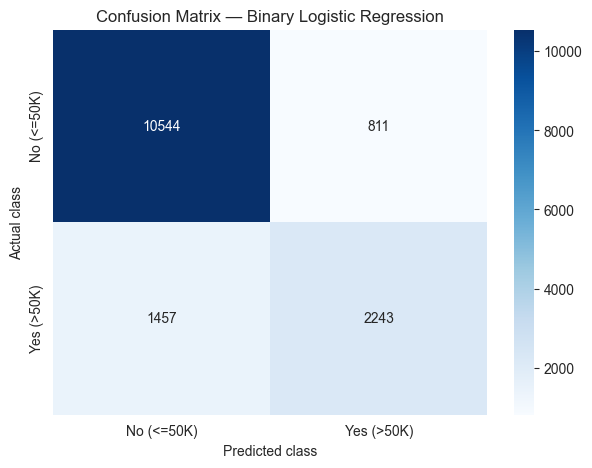

In [18]:
cm = confusion_matrix(y_test_log, y_pred_log, labels=[0, 1])

tn, fp, fn, tp = cm.ravel()

print("Confusion matrix:")
print(cm)
print(f"\nTrue negatives  (correctly predicted <=50K): {tn}")
print(f"False positives (predicted >50K, actually <=50K): {fp}")
print(f"False negatives (predicted <=50K, actually >50K): {fn}")
print(f"True positives  (correctly predicted >50K): {tp}")

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No (<=50K)", "Yes (>50K)"],
    yticklabels=["No (<=50K)", "Yes (>50K)"]
)

plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.title("Confusion Matrix — Binary Logistic Regression")
plt.show()

#### Classification metrics (requirement 4)

In [19]:
accuracy = accuracy_score(y_test_log, y_pred_log)
precision = precision_score(y_test_log, y_pred_log, zero_division=0)
recall = recall_score(y_test_log, y_pred_log, zero_division=0)
f1 = f1_score(y_test_log, y_pred_log, zero_division=0)
auc = roc_auc_score(y_test_log, y_prob_log)

classification_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Value": [accuracy, precision, recall, f1, auc]
})

display(classification_metrics.round(4))

print(f"Baseline accuracy (always predicting <=50K) = {1 - y_test_log.mean():.4f}")

,Metric,Value
0,Accuracy,0.8494
1,Precision,0.7344
2,Recall,0.6062
3,F1-score,0.6642
4,ROC-AUC,0.9045


Baseline accuracy (always predicting <=50K) = 0.7542


**How to read the metrics:**
- **Accuracy:** share of all people classified correctly. Compare it with the baseline: about 75% of people earn ≤50K, so a model that always says "No" would already be about 75% accurate.
- **Precision:** of the people the model predicts earn >50K, the share who actually do.
- **Recall:** of the people who actually earn >50K, the share the model finds.
- **F1-score:** balance between precision and recall.
- **ROC-AUC:** how well the model ranks high earners above low earners across all thresholds (0.5 = random guessing, 1.0 = perfect).

#### Classification report

In [20]:
print("Classification report:")

print(
    classification_report(
        y_test_log,
        y_pred_log,
        target_names=["No (<=50K)", "Yes (>50K)"],
        zero_division=0
    )
)

Classification report:
              precision    recall  f1-score   support

  No (<=50K)       0.88      0.93      0.90     11355
  Yes (>50K)       0.73      0.61      0.66      3700

    accuracy                           0.85     15055
   macro avg       0.81      0.77      0.78     15055
weighted avg       0.84      0.85      0.84     15055



#### ROC curve and AUC

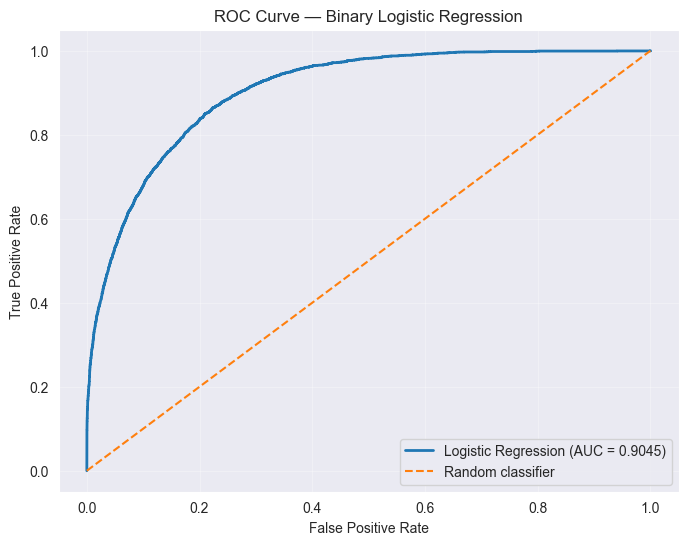

ROC-AUC = 0.9045


In [21]:
fpr, tpr, thresholds = roc_curve(y_test_log, y_prob_log)

roc_auc = roc_auc_score(y_test_log, y_prob_log)

plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, linewidth=2, label=f"Logistic Regression (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Binary Logistic Regression")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"ROC-AUC = {roc_auc:.4f}")

#### User-defined prediction (requirement 5)

Enter a new person's characteristics in readable form. The helper function turns them into the same 41 encoded columns as the training data (a reference category such as `Husband` or `Federal-gov` simply means all of that variable's columns are 0). The model then predicts the probability of "No" (≤50K) and "Yes" (>50K).

In [22]:
# Replace with the desired values
new_person = {
    "age": 40,
    "education-num": 13,                    # 9 = HS-grad, 13 = Bachelors, 16 = Doctorate
    "sex": "Male",
    "capital-gain": 0,
    "capital-loss": 0,
    "hours-per-week": 45,
    "native-country": "United-States",
    "workclass": "Private",
    "marital-status": "Married-civ-spouse",
    "occupation": "Exec-managerial",
    "relationship": "Husband",
    "race": "White"
}


def encode_new_person(person, columns):
    """Turn readable values into one row with the same encoded columns as the training data."""
    row = pd.DataFrame(0, index=[0], columns=columns)

    for variable in ["age", "education-num", "hours-per-week"]:
        row[variable] = person[variable]

    # The same transformations as in the descriptive statistics notebook
    row["capital-gain-log"] = np.log1p(person["capital-gain"])
    row["capital-loss-log"] = np.log1p(person["capital-loss"])
    row["has-capital"] = 1 if (person["capital-gain"] > 0 or person["capital-loss"] > 0) else 0

    row["sex"] = 1 if person["sex"] == "Male" else 0
    row["is_us"] = 1 if person["native-country"] == "United-States" else 0

    for variable in ["workclass", "marital-status", "occupation", "relationship", "race"]:
        column = f"{variable}_{person[variable]}"
        if column in columns:
            row[column] = 1
        # otherwise it is the reference category, so all columns stay 0

    return row


new_person_encoded = encode_new_person(new_person, logistic_predictors)

probabilities = logistic_model.predict_proba(new_person_encoded)[0]

prob_no = probabilities[0]
prob_yes = probabilities[1]

prediction = "Yes (>50K)" if prob_yes >= classification_threshold else "No (<=50K)"

print("=" * 50)
print("LOGISTIC REGRESSION PREDICTION")
print("=" * 50)

print("\nInput values:")
display(pd.DataFrame([new_person]))

print(f"\nProbability of No  (<=50K): {prob_no:.4f} ({prob_no * 100:.2f}%)")
print(f"Probability of Yes (>50K):  {prob_yes:.4f} ({prob_yes * 100:.2f}%)")

print(f"\nPredicted income: {prediction}")

LOGISTIC REGRESSION PREDICTION

Input values:


,age,education-num,sex,capital-gain,capital-loss,hours-per-week,native-country,workclass,marital-status,occupation,relationship,race
0,40,13,Male,0,0,45,United-States,Private,Married-civ-spouse,Exec-managerial,Husband,White



Probability of No  (<=50K): 0.2872 (28.72%)
Probability of Yes (>50K):  0.7128 (71.28%)

Predicted income: Yes (>50K)
